In [70]:
# IMPORT LIBRARY

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# MEMBUAT DATASET SINTETIS

np.random.seed(42)

jumlah_data = 300

pengalaman = np.random.uniform(
    0, 20, jumlah_data
)

edu = np.random.choice(
    [0, 1, 2],
    jumlah_data
)  # SMA=0, D3=1, S1=2

kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    jumlah_data
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, jumlah_data)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

In [72]:
# INFORMASI DATASET

print("Shape Dataset:", df.shape)

display(df.head())

display(
    df.describe().round(2)
)

Shape Dataset: (300, 4)


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22


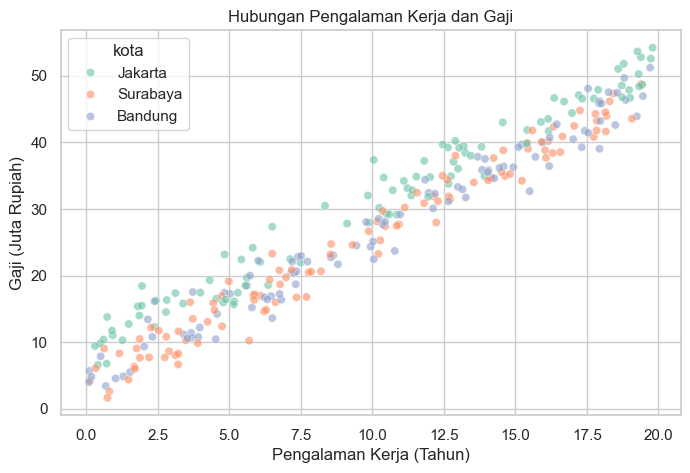

In [73]:
# SCATTER PLOT

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title(
    'Hubungan Pengalaman Kerja dan Gaji'
)

plt.xlabel('Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')

plt.show()

In [74]:
# ONE HOT ENCODING

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom Setelah Encoding:\n")

print(df.columns.tolist())

Kolom Setelah Encoding:

['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


In [75]:
# FEATURE DAN TARGET

X = df.drop('gaji', axis=1)

y = df['gaji']

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (300, 4)
Shape y : (300,)


In [76]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    f"Data Training : {X_train.shape[0]} baris"
)

print(
    f"Data Testing  : {X_test.shape[0]} baris"
)

Data Training : 240 baris
Data Testing  : 60 baris


In [79]:
# FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Mean Training:")
print(scaler.mean_.round(2))

print("\nStandar Deviasi:")
print(scaler.scale_.round(2))

Mean Training:
[9.87 0.91 0.35 0.35]

Standar Deviasi:
[5.93 0.84 0.48 0.48]


In [81]:
# MEMBUAT DAN MELATIH MODEL

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[13.04, 1.19, 1.84,-0.29]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.51
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[19.36,15.64,15.17,10.51]"


In [82]:
# KOEFISIEN MODEL

print(
    f"Intercept (β₀): {model.intercept_:.3f}"
)

koefisien = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

koefisien = koefisien.sort_values(
    by='Koefisien',
    ascending=False
)

display(koefisien)

Intercept (β₀): 27.514


,Fitur,Koefisien
0,pengalaman,13.042
2,kota_Jakarta,1.837
1,edu,1.188
3,kota_Surabaya,-0.292


In [83]:
# PREDIKSI

y_pred = model.predict(
    X_test_scaled
)

In [84]:
# EVALUASI MODEL

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = root_mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("=== HASIL EVALUASI ===\n")

print(
    f"MAE  : {mae:.3f} juta rupiah"
)

print(
    f"RMSE : {rmse:.3f} juta rupiah"
)

print(
    f"R²   : {r2:.4f}"
)

print(
    f"Variasi Data yang Dijelaskan: {r2*100:.1f}%"
)

=== HASIL EVALUASI ===

MAE  : 1.649 juta rupiah
RMSE : 2.123 juta rupiah
R²   : 0.9740
Variasi Data yang Dijelaskan: 97.4%


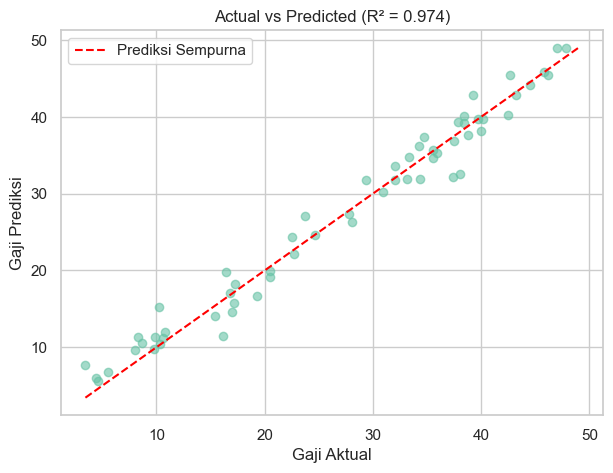

In [89]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

batas = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    batas,
    batas,
    'r--',
    label='Prediksi Sempurna'
)

plt.title(
    f'Actual vs Predicted (R² = {r2:.3f})'
)

plt.xlabel('Gaji Aktual')
plt.ylabel('Gaji Prediksi')

plt.legend()

plt.show()

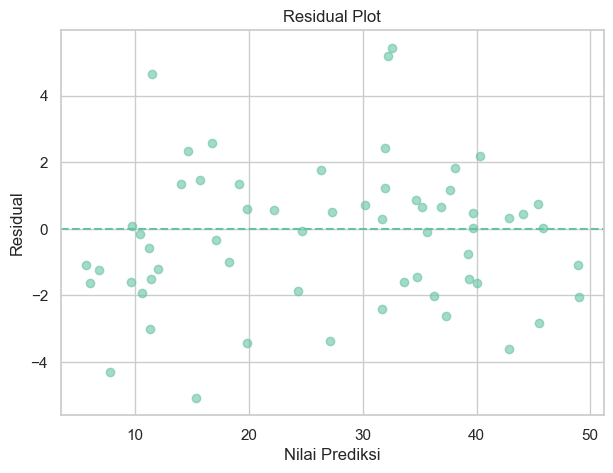

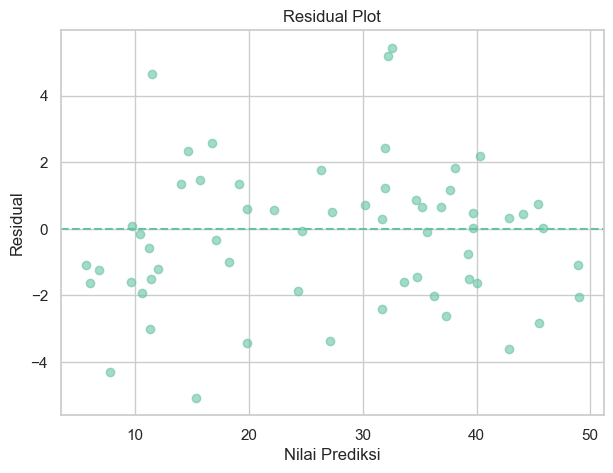

In [91]:
# ==========================================
# RESIDUAL PLOT
# ==========================================

residual = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residual,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Residual Plot')

plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')

plt.show()

<Figure size 640x480 with 0 Axes>